# CIFAR-10 — Data Augmentation & Transfert Learning avec TensorFlow / Keras

> Ce notebook a pour objectif de valider les compétences **C4.3 - Créer un algorithme robuste et précis en configurant un réseau de neurones pré-entraîné profond afin de répondre à des problématiques de prédiction sur des volumes de données massifs** et **C4.4 - Créer des données non-structurées en élaborant des réseaux de neurones adverses afin de construire de nouvelles bases d’entraînement pour des applications d'intelligence artificielle**.

## Data Augmentation

La **data augmentation** consiste à appliquer des transformations aux exemples d'entraînement afin de produire des variantes plausibles.

Un modèle peut mémoriser des détails propres aux images d'entraînement. L'augmentation agit comme une forme de **régularisation** : elle pousse le modèle à apprendre des caractéristiques plus robustes.

On cherche donc à enrichir le jeu d'entraînement en introduisant des variations qui ne changent pas la classe :

- translation ou recadrage léger,
- retournement horizontal,
- changement modéré de contraste ou de luminosité,
- rotations...

In [5]:
import random

import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

In [6]:
SEED = 73
BATCH_SIZE = 32

EPOCHS_HEAD = 3
EPOCHS_FINE = 3

TRAIN_LIMIT = 5000
TEST_LIMIT = 1000

IMAGE_SIZE = 96

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

## Chargement et inspection du dataset CIFAR-10

CIFAR-10 contient 60 000 images couleur réparties dans 10 classes :

- `airplane`
- `automobile`
- `bird`
- `cat`
- `deer`
- `dog`
- `frog`
- `horse`
- `ship`
- `truck`

Les images originales font **32×32 pixels**.

Nous commençons par observer les données avant toute transformation.

In [4]:
CLASS_NAMES = [
    "airplane",
    "automobile",
    "bird",
    "cat",
    "deer",
    "dog",
    "frog",
    "horse",
    "ship",
    "truck",
]

(x_train_full, y_train_full), (x_test_full, y_test_full) = (
    tf.keras.datasets.cifar10.load_data()
)

y_train_full = y_train_full.squeeze()
y_test_full = y_test_full.squeeze()

print("Train   :", x_train_full.shape, y_train_full.shape)
print("Test    :", x_test_full.shape, y_test_full.shape)
print("Classes :", CLASS_NAMES)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2780s 16us/step
Train   : (50000, 32, 32, 3) (50000,)
Test    : (10000, 32, 32, 3) (10000,)
Classes : ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


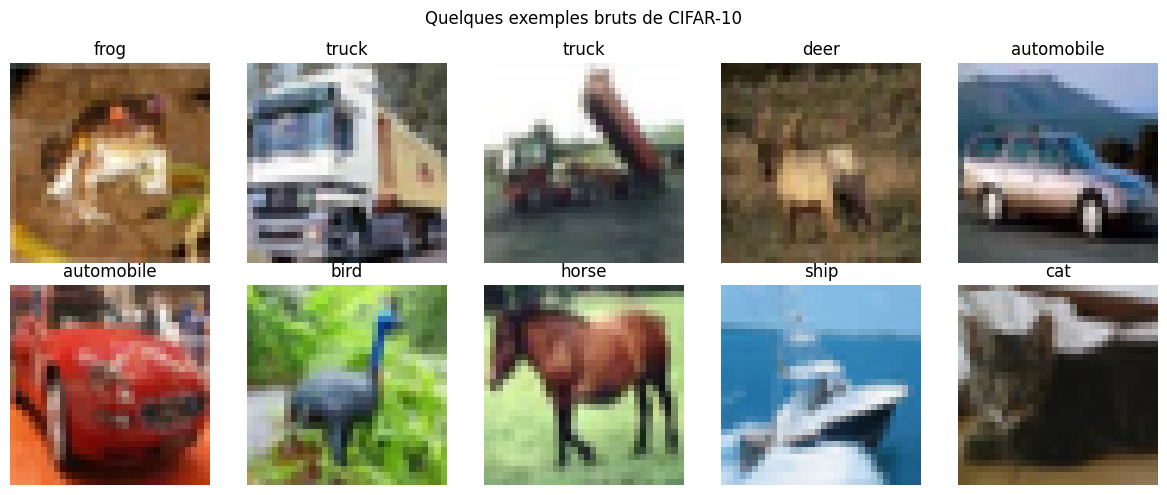

In [7]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5))

for ax, i in zip(axes.ravel(), range(10), strict=False):
    ax.imshow(x_train_full[i])
    ax.set_title(CLASS_NAMES[y_train_full[i]])
    ax.axis("off")

plt.suptitle("Quelques exemples bruts de CIFAR-10")
plt.tight_layout()
plt.show()

## Construction de la pipeline de data augmentation

Keras permet de placer les transformations directement dans le modèle avec les couches de preprocessing :

- `RandomFlip`
- `RandomRotation`
- `RandomZoom`
- `RandomContrast`

Nous allons comparer conceptuellement deux configurations :

- **Baseline :** redimensionnement + preprocessing du modèle,
- **Augmentation :** transformations aléatoires + preprocessing.

Les transformations sont appliquées uniquement pendant l'entraînement.

In [8]:
# Sous-ensembles
train_size = len(x_train_full) if TRAIN_LIMIT is None else min(TRAIN_LIMIT, len(x_train_full))
test_size = len(x_test_full) if TEST_LIMIT is None else min(TEST_LIMIT, len(x_test_full))

x_train = x_train_full[:train_size]
y_train = y_train_full[:train_size]

x_test = x_test_full[:test_size]
y_test = y_test_full[:test_size]

print("Train utilisé :", x_train.shape)
print("Test utilisé  :", x_test.shape)

Train utilisé : (5000, 32, 32, 3)
Test utilisé  : (1000, 32, 32, 3)


In [14]:
def build_data_augmentation():
    return tf.keras.Sequential([
        tf.keras.layers.RandomFlip("horizontal"),
        tf.keras.layers.RandomRotation(0.08),
        tf.keras.layers.RandomZoom(0.15),
        tf.keras.layers.RandomContrast(0.15),
    ], name="data_augmentation")

data_augmentation = build_data_augmentation()

## Visualisation concrète des augmentations

Une même image peut produire des variantes différentes à chaque passage dans la pipeline. Le modèle ne voit donc pas nécessairement exactement la même représentation de l'image à chaque époque.

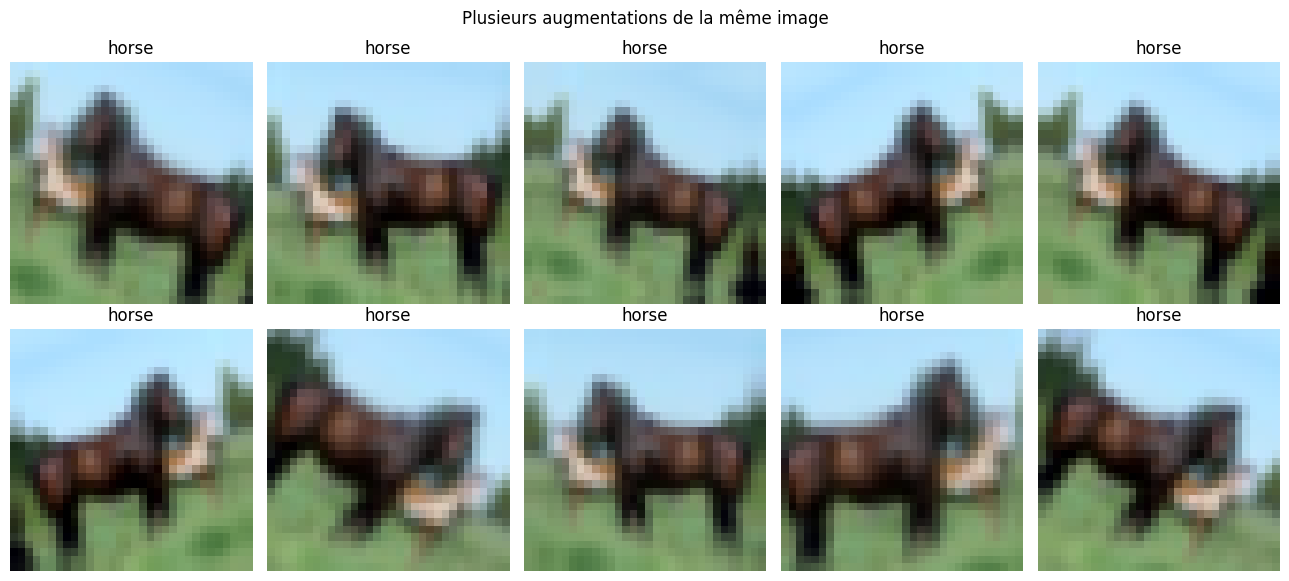

In [15]:
sample = tf.convert_to_tensor(x_train[12:13])

fig, axes = plt.subplots(2, 5, figsize=(13, 6))

for ax in axes.ravel():
    augmented = data_augmentation(sample, training=True)
    image = tf.clip_by_value(augmented[0] / 255.0, 0.0, 1.0)

    ax.imshow(image)
    ax.set_title(CLASS_NAMES[y_train[12]])
    ax.axis("off")

plt.suptitle("Plusieurs augmentations de la même image")
plt.tight_layout()
plt.show()

Observations :

- la classe reste identique,
- l'apparence et la géométrie varient,
- chaque passage peut produire une version différente.

## Préparation des `tf.data.Dataset`

Nous normalisons ici les pixels en les convertissant en `float32`. Le modèle MobileNetV3Small avec preprocessing intégré prend ensuite en charge la transformation appropriée pour ses poids pré-entraînés.

In [12]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = tf.data.Dataset.from_tensor_slices((x_train, y_train))
train_ds = train_ds.shuffle(
    buffer_size=min(len(x_train), 10000),
    seed=SEED,
    reshuffle_each_iteration=True
)
train_ds = train_ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

test_ds = tf.data.Dataset.from_tensor_slices((x_test, y_test))
test_ds = test_ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

print("Train batches :", tf.data.experimental.cardinality(train_ds).numpy())
print("Test batches  :", tf.data.experimental.cardinality(test_ds).numpy())

Train batches : 157
Test batches  : 32


## Transfert learning et fine-tuning

Le **transfer learning** consiste à réutiliser des représentations apprises sur une autre tâche.

Avec un modèle pré-entraîné :

1. on conserve le backbone,
2. on remplace la tête de classification,
3. on entraîne la tête,
4. on peut dégeler une partie du backbone,
5. on poursuit avec un learning rate plus faible.

Cette dernière étape correspond au **fine-tuning**.

In [23]:
def build_model(use_augmentation: bool, model_name: str = "cifar10_mobilenetv3small"):
    # MobileNetV3Small pré-entraîné sur ImageNet.
    # include_top=False permet de supprimer le classifieur ImageNet.
    base_model = tf.keras.applications.MobileNetV3Small(
        input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3),
        include_top=False,
        weights="imagenet",
        include_preprocessing=True
    )

    # On gèle le backbone pour la phase de transfer learning
    base_model.trainable = False

    # Entrée CIFAR-10 : 32x32x3
    inputs = tf.keras.Input(shape=(32, 32, 3), name="image")

    # Redimensionnement
    x = tf.keras.layers.Resizing(IMAGE_SIZE, IMAGE_SIZE)(inputs)

    # Data augmentation
    if use_augmentation:
        data_augmentation = build_data_augmentation()
        x = data_augmentation(x)

    # Backbone pré-entraîné
    x = base_model(x, training=False)

    # Tête de classification CIFAR-10
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dropout(0.2)(x)

    outputs = tf.keras.layers.Dense(10, activation="softmax", name="classifier")(x)

    model = tf.keras.Model(
        inputs,
        outputs,
        name=model_name
    )

    return model


model_no_aug = build_model(use_augmentation=False, model_name="cifar10_mobilenetv3small_no_aug")
model_aug = build_model(use_augmentation=True, model_name="cifar10_mobilenetv3small_aug")

c:\Users\USER.LAPTOP-LT9LCNMM\m2i\M2i_CDSD_Projet\.venv\Lib\site-packages\keras\src\applications\mobilenet_v3.py:454: UserWarning: `input_shape` is undefined or non-square, or `rows` is not 224. Weights for input shape (224, 224) will be loaded as the default.
  return MobileNetV3(


## Phase 1 — entraînement de la tête uniquement

On garde le backbone gelé.

Cela permet de limiter le nombre de paramètres mis à jour, offrant un entraînement rapide.

In [24]:
def count_parameters(model):
    total = np.sum([np.prod(v.shape) for v in model.trainable_variables])
    return int(total)

print(f"Modèle : {model_no_aug.name}")
print("Paramètres entraînables :", count_parameters(model_no_aug))

print()
print(f"Modèle : {model_aug.name}")
print("Paramètres entraînables :", count_parameters(model_aug))

Modèle : cifar10_mobilenetv3small_no_aug
Paramètres entraînables : 5770

Modèle : cifar10_mobilenetv3small_aug
Paramètres entraînables : 5770


In [18]:
model_no_aug.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history_head_no_aug = model_no_aug.fit(
    train_ds,
    validation_data=test_ds,
    epochs=EPOCHS_HEAD,
    verbose=1
)

Epoch 1/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 25s 96ms/step - accuracy: 0.4792 - loss: 1.5169 - val_accuracy: 0.6700 - val_loss: 0.9646
Epoch 2/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 13s 80ms/step - accuracy: 0.6884 - loss: 0.9266 - val_accuracy: 0.7180 - val_loss: 0.8011
Epoch 3/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 14s 87ms/step - accuracy: 0.7294 - loss: 0.7835 - val_accuracy: 0.7330 - val_loss: 0.7540


In [19]:
model_aug.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history_head_aug = model_aug.fit(
    train_ds,
    validation_data=test_ds,
    epochs=EPOCHS_HEAD,
    verbose=1
)

Epoch 1/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 31s 136ms/step - accuracy: 0.4056 - loss: 1.7036 - val_accuracy: 0.6430 - val_loss: 1.0483
Epoch 2/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 24s 152ms/step - accuracy: 0.5936 - loss: 1.1535 - val_accuracy: 0.6900 - val_loss: 0.8769
Epoch 3/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 21s 135ms/step - accuracy: 0.6284 - loss: 1.0389 - val_accuracy: 0.7090 - val_loss: 0.8273


## Phase 2 — fine-tuning partiel du backbone

Nous dégelons les dernières couches du backbone.

Les couches initiales restent gelées : elles capturent souvent des caractéristiques visuelles relativement générales, alors que les couches profondes sont davantage spécialisées.

In [25]:
def prepare_for_fine_tuning(model, n_layers_to_unfreeze: int = 20):
    # Récupérer le backbone dans le modèle
    base_model = next(
        layer for layer in model.layers
        if isinstance(layer, tf.keras.Model)
        and "MobileNetV3Small" in layer.name
    )

    # Autoriser le fine-tuning du backbone
    base_model.trainable = True

    # Nombre de couches du backbone à conserver gelées
    frozen_layers = max(
        0,
        len(base_model.layers) - n_layers_to_unfreeze
    )

    # Geler les premières couches
    for layer in base_model.layers[:frozen_layers]:
        layer.trainable = False

    # Dégeler les dernières couches
    for layer in base_model.layers[frozen_layers:]:
        layer.trainable = True

    print(f"Modèle : {model.name}")
    print(f"Couches totales   : {len(base_model.layers)}")
    print(f"Couches gelées    : {frozen_layers}")
    print(f"Couches dégelées  : {len(base_model.layers) - frozen_layers}")


prepare_for_fine_tuning(model_no_aug, n_layers_to_unfreeze=20)
print("Paramètres entraînables :", count_parameters(model_no_aug))

print()
prepare_for_fine_tuning(model_aug, n_layers_to_unfreeze=20)
print("Paramètres entraînables :", count_parameters(model_aug))

Modèle : cifar10_mobilenetv3small_no_aug
Couches totales   : 157
Couches gelées    : 137
Couches dégelées  : 20
Paramètres entraînables : 356506

Modèle : cifar10_mobilenetv3small_aug
Couches totales   : 157
Couches gelées    : 137
Couches dégelées  : 20
Paramètres entraînables : 356506


In [26]:
# Learning rate beaucoup plus faible pour le fine-tuning.
model_no_aug.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history_fine_no_aug = model_no_aug.fit(
    train_ds,
    validation_data=test_ds,
    initial_epoch=EPOCHS_HEAD,
    epochs=EPOCHS_HEAD + EPOCHS_FINE,
    verbose=1
)

Epoch 4/6
157/157 ━━━━━━━━━━━━━━━━━━━━ 30s 116ms/step - accuracy: 0.2338 - loss: 2.3647 - val_accuracy: 0.3560 - val_loss: 1.8110
Epoch 5/6
157/157 ━━━━━━━━━━━━━━━━━━━━ 17s 111ms/step - accuracy: 0.5050 - loss: 1.4546 - val_accuracy: 0.5290 - val_loss: 1.3565
Epoch 6/6
157/157 ━━━━━━━━━━━━━━━━━━━━ 21s 114ms/step - accuracy: 0.6228 - loss: 1.1072 - val_accuracy: 0.6230 - val_loss: 1.1044


In [27]:
# Learning rate beaucoup plus faible pour le fine-tuning.
model_aug.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history_fine_aug = model_aug.fit(
    train_ds,
    validation_data=test_ds,
    initial_epoch=EPOCHS_HEAD,
    epochs=EPOCHS_HEAD + EPOCHS_FINE,
    verbose=1
)

Epoch 4/6
157/157 ━━━━━━━━━━━━━━━━━━━━ 42s 168ms/step - accuracy: 0.2198 - loss: 2.4013 - val_accuracy: 0.3460 - val_loss: 1.8967
Epoch 5/6
157/157 ━━━━━━━━━━━━━━━━━━━━ 26s 163ms/step - accuracy: 0.4390 - loss: 1.6487 - val_accuracy: 0.5150 - val_loss: 1.4056
Epoch 6/6
157/157 ━━━━━━━━━━━━━━━━━━━━ 26s 166ms/step - accuracy: 0.5338 - loss: 1.3451 - val_accuracy: 0.6100 - val_loss: 1.1504


## Courbes d'apprentissage

On observe :

- `accuracy` d'entraînement,
- `val_accuracy`,
- `loss`,
- `val_loss`.

L'écart entre entraînement et validation peut donner des indications sur le sur-apprentissage.

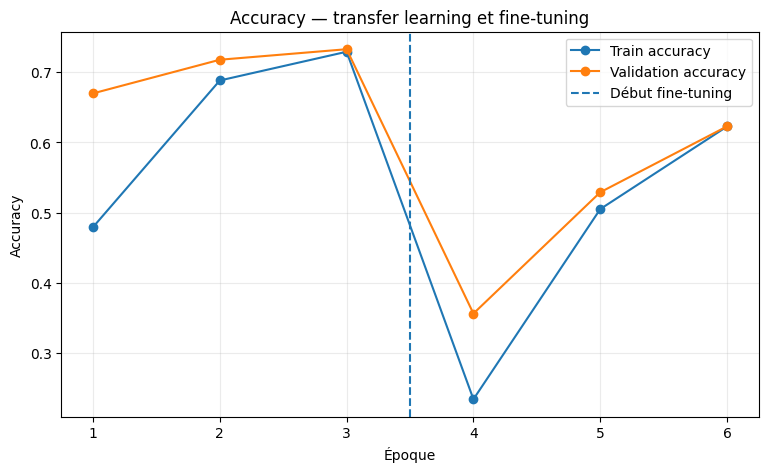

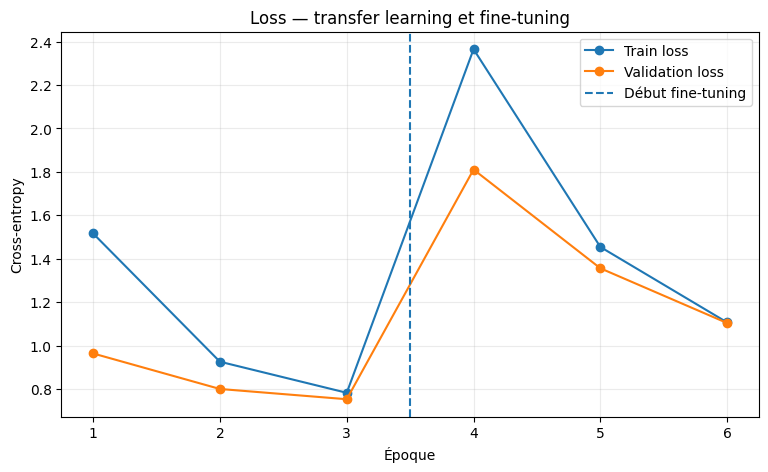

In [28]:
def merge_histories(h1, h2):
    history = {}
    keys = set(h1.history) | set(h2.history)

    for key in keys:
        history[key] = h1.history.get(key, []) + h2.history.get(key, [])

    return history

history = merge_histories(history_head_no_aug, history_fine_no_aug)

epochs = range(1, len(history["accuracy"]) + 1)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(epochs, history["accuracy"], marker="o", label="Train accuracy")
ax.plot(epochs, history["val_accuracy"], marker="o", label="Validation accuracy")
ax.axvline(EPOCHS_HEAD + 0.5, linestyle="--", label="Début fine-tuning")
ax.set_xlabel("Époque")
ax.set_ylabel("Accuracy")
ax.set_title("Accuracy — transfer learning et fine-tuning")
ax.legend()
ax.grid(True, alpha=0.25)
plt.show()

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(epochs, history["loss"], marker="o", label="Train loss")
ax.plot(epochs, history["val_loss"], marker="o", label="Validation loss")
ax.axvline(EPOCHS_HEAD + 0.5, linestyle="--", label="Début fine-tuning")
ax.set_xlabel("Époque")
ax.set_ylabel("Cross-entropy")
ax.set_title("Loss — transfer learning et fine-tuning")
ax.legend()
ax.grid(True, alpha=0.25)
plt.show()

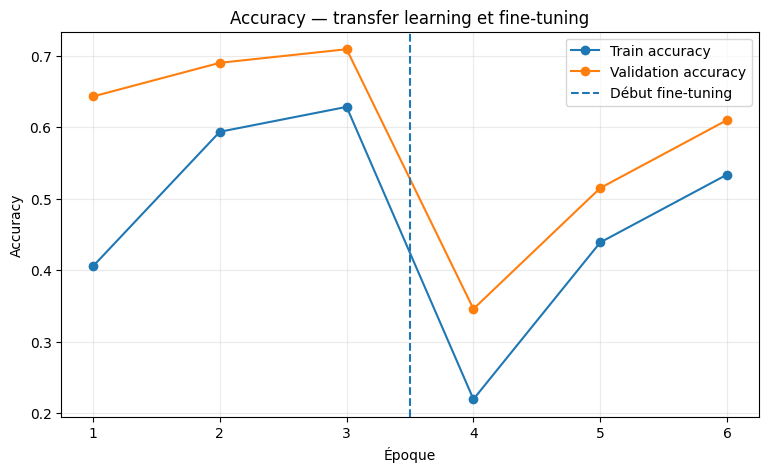

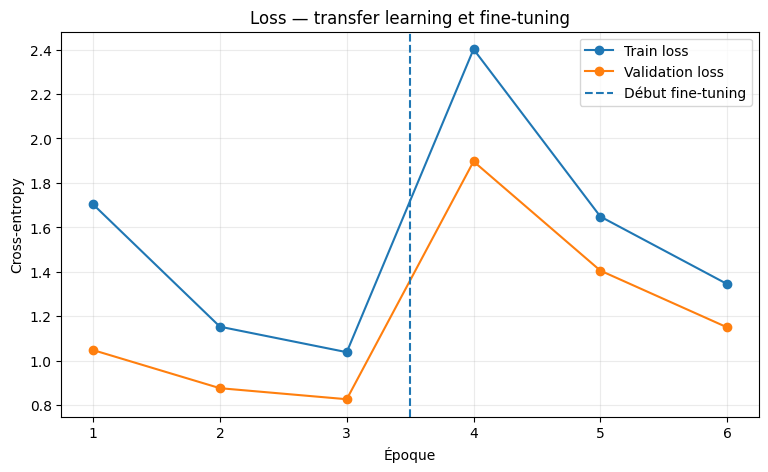

In [29]:
history = merge_histories(history_head_aug, history_fine_aug)

epochs = range(1, len(history["accuracy"]) + 1)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(epochs, history["accuracy"], marker="o", label="Train accuracy")
ax.plot(epochs, history["val_accuracy"], marker="o", label="Validation accuracy")
ax.axvline(EPOCHS_HEAD + 0.5, linestyle="--", label="Début fine-tuning")
ax.set_xlabel("Époque")
ax.set_ylabel("Accuracy")
ax.set_title("Accuracy — transfer learning et fine-tuning")
ax.legend()
ax.grid(True, alpha=0.25)
plt.show()

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(epochs, history["loss"], marker="o", label="Train loss")
ax.plot(epochs, history["val_loss"], marker="o", label="Validation loss")
ax.axvline(EPOCHS_HEAD + 0.5, linestyle="--", label="Début fine-tuning")
ax.set_xlabel("Époque")
ax.set_ylabel("Cross-entropy")
ax.set_title("Loss — transfer learning et fine-tuning")
ax.legend()
ax.grid(True, alpha=0.25)
plt.show()

Observations :
- Pour le modèle sans data augmentation, les courbes d’apprentissage du jeu d’entraînement et de validation se croisent rapidement, ce qui peut indiquer une généralisation moins stable et un risque accru de surapprentissage.
- Pour le modèle avec data augmentation, la convergence est plus progressive. Les transformations appliquées aux données introduisent davantage de variabilité pendant l’entraînement et jouent ainsi un rôle régularisant, ce qui contribue à limiter le surapprentissage et à améliorer la généralisation.

## Évaluation du modèle par classe

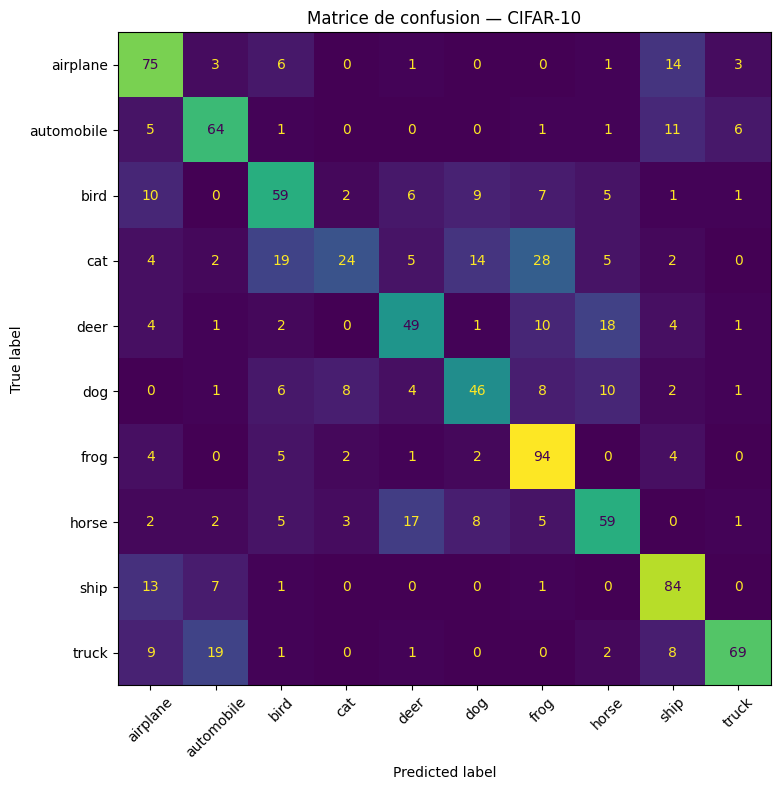

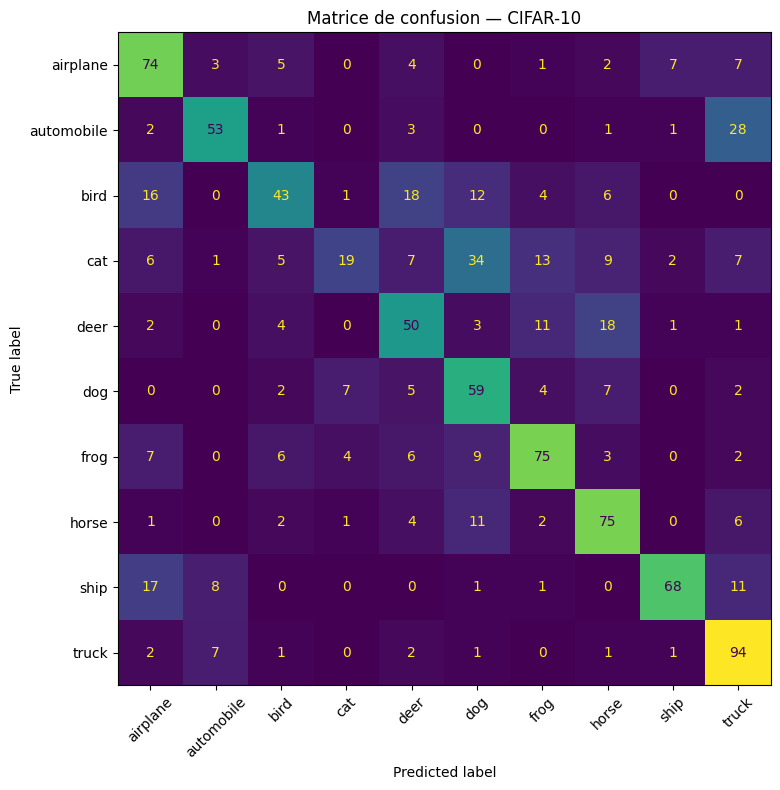

In [31]:
def plot_confusion_matrix(model):
    y_true = []
    y_pred = []

    for images, labels in test_ds:
        probabilities = model.predict(images, verbose=0)
        predictions = np.argmax(probabilities, axis=1)

        y_true.extend(labels.numpy())
        y_pred.extend(predictions)

    cm = confusion_matrix(y_true, y_pred, labels=list(range(10)))

    fig, ax = plt.subplots(figsize=(8, 8))
    disp = ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES)
    disp.plot(ax=ax, xticks_rotation=45, colorbar=False)
    ax.set_title("Matrice de confusion — CIFAR-10")
    plt.tight_layout()
    plt.show()


plot_confusion_matrix(model_no_aug)
plot_confusion_matrix(model_aug)

Observations :
- Les modèles ont été entraînés sur un faible nombre d'époques et sur un petit échantillon du dataset. Il est difficile de comparer les performances des deux approches.